In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load feature-engineered dataset
file_path = "../data/retail_sales_features.csv"

df = pd.read_csv(file_path)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Forecasting dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Forecasting dataset loaded successfully!
Rows: 73000
Columns: 26
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


In [2]:
print("Columns available for forecasting:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns available for forecasting:
['Date', 'Store_ID', 'Store_Location', 'Product_ID', 'Product_Category', 'Product_Subcategory', 'Brand', 'Unit_Price', 'Units_Sold', 'Total_Sales', 'Discount_Percentage', 'Revenue', 'Customer_Type', 'Payment_Mode', 'Promotion_Applied', 'Stock_On_Hand', 'Store_Rating', 'Region', 'Holiday_Flag', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'Day_of_Week', 'Week_of_Year']

Missing values:
0

Duplicate rows:
0


In [3]:
daily_sales = (
    df.groupby("Date")["Total_Sales"]
    .sum()
    .reset_index()
)

daily_sales = daily_sales.sort_values("Date")

print("Daily sales dataset created successfully!")
print("Rows:", daily_sales.shape[0])
print("Columns:", daily_sales.shape[1])

print("\nFirst 5 rows:")
print(daily_sales.head())

Daily sales dataset created successfully!
Rows: 731
Columns: 2

First 5 rows:
        Date  Total_Sales
0 2023-01-01  58573510.66
1 2023-01-02  54332756.95
2 2023-01-03  72712543.16
3 2023-01-04  67110537.19
4 2023-01-05  38916642.05


In [4]:
daily_sales = (
    df.groupby("Date")["Total_Sales"]
    .sum()
    .reset_index()
)

daily_sales = daily_sales.sort_values("Date")

print("Daily sales dataset created successfully!")
print("Rows:", daily_sales.shape[0])
print("Columns:", daily_sales.shape[1])

print("\nFirst 5 rows:")
print(daily_sales.head())

Daily sales dataset created successfully!
Rows: 731
Columns: 2

First 5 rows:
        Date  Total_Sales
0 2023-01-01  58573510.66
1 2023-01-02  54332756.95
2 2023-01-03  72712543.16
3 2023-01-04  67110537.19
4 2023-01-05  38916642.05


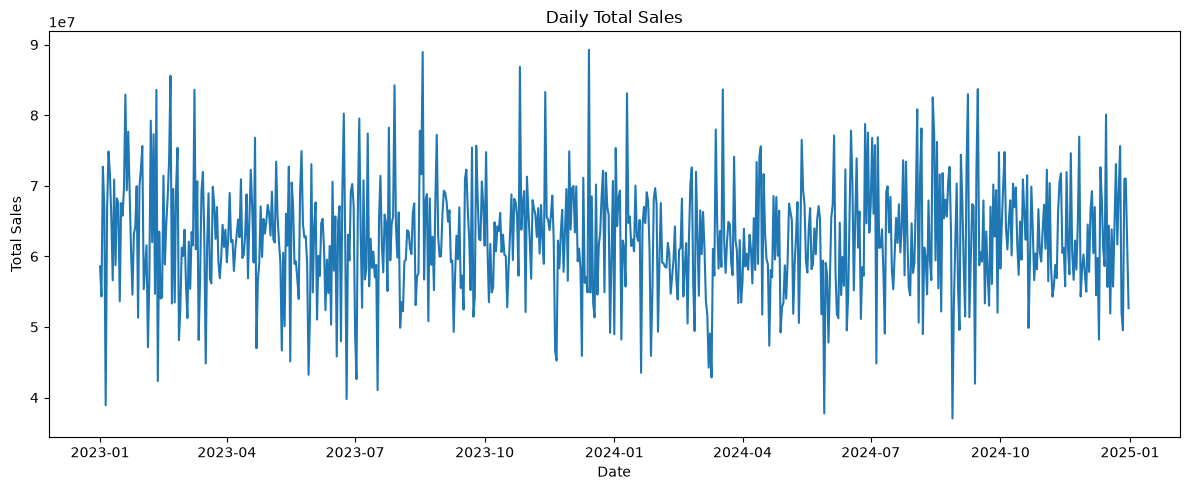

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Total_Sales"]
)

plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [6]:
# Create monthly sales dataset

monthly_sales = (
    daily_sales
    .set_index("Date")
    .resample("MS")["Total_Sales"]
    .sum()
    .reset_index()
)

print("Monthly sales dataset created successfully!")
print("Rows:", monthly_sales.shape[0])
print("Columns:", monthly_sales.shape[1])

print("\nMonthly sales:")
print(monthly_sales)

Monthly sales dataset created successfully!
Rows: 24
Columns: 2

Monthly sales:
         Date   Total_Sales
0  2023-01-01  2.030645e+09
1  2023-02-01  1.756334e+09
2  2023-03-01  1.918315e+09
3  2023-04-01  1.895609e+09
4  2023-05-01  1.913626e+09
5  2023-06-01  1.825544e+09
6  2023-07-01  1.930047e+09
7  2023-08-01  1.946579e+09
8  2023-09-01  1.898996e+09
9  2023-10-01  1.958906e+09
10 2023-11-01  1.903711e+09
11 2023-12-01  1.948264e+09
12 2024-01-01  1.954776e+09
13 2024-02-01  1.741072e+09
14 2024-03-01  1.869503e+09
15 2024-04-01  1.829423e+09
16 2024-05-01  1.890228e+09
17 2024-06-01  1.874205e+09
18 2024-07-01  1.964145e+09
19 2024-08-01  1.990362e+09
20 2024-09-01  1.882088e+09
21 2024-10-01  1.975270e+09
22 2024-11-01  1.873009e+09
23 2024-12-01  1.937433e+09


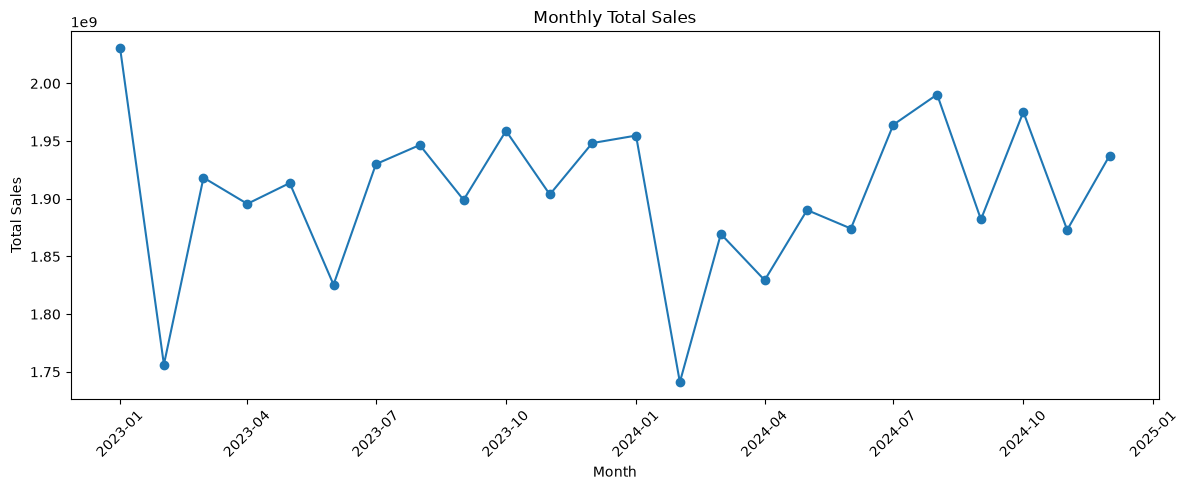

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Total_Sales"],
    marker="o"
)

plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
print("Monthly dataset information:")
print(monthly_sales.info())

print("\nMissing values:")
print(monthly_sales.isnull().sum())

print("\nDuplicate rows:")
print(monthly_sales.duplicated().sum())

Monthly dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         24 non-null     datetime64[us]
 1   Total_Sales  24 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 512.0 bytes
None

Missing values:
Date           0
Total_Sales    0
dtype: int64

Duplicate rows:
0


In [9]:
# Train-Test Split

train = monthly_sales.iloc[:-6].copy()
test = monthly_sales.iloc[-6:].copy()

print("Training data:")
print("Rows:", train.shape[0])
print("Start:", train["Date"].min())
print("End:", train["Date"].max())

print("\nTesting data:")
print("Rows:", test.shape[0])
print("Start:", test["Date"].min())
print("End:", test["Date"].max())

Training data:
Rows: 18
Start: 2023-01-01 00:00:00
End: 2024-06-01 00:00:00

Testing data:
Rows: 6
Start: 2024-07-01 00:00:00
End: 2024-12-01 00:00:00


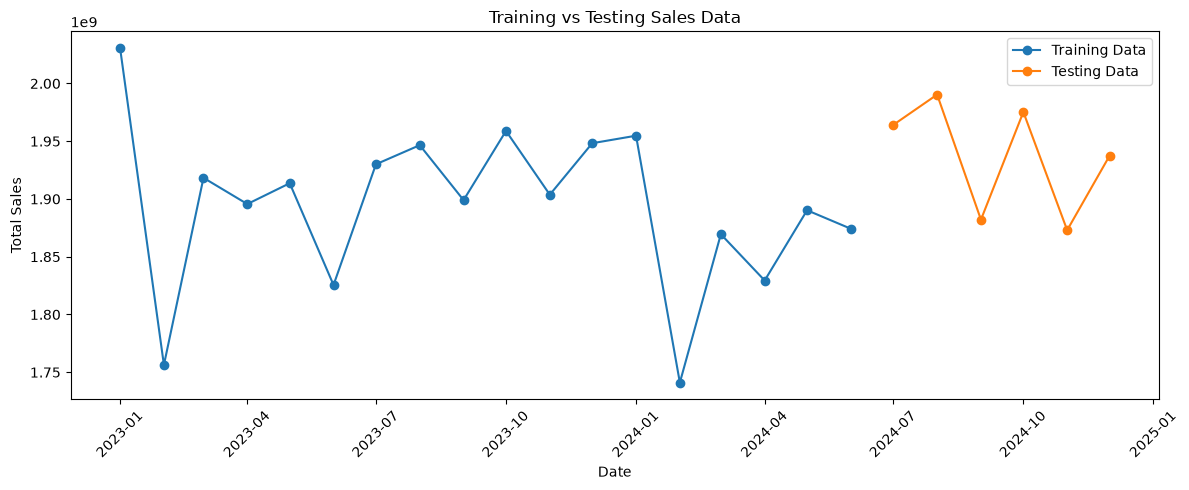

In [10]:
# Visualize training and testing data

plt.figure(figsize=(12, 5))

plt.plot(
    train["Date"],
    train["Total_Sales"],
    marker="o",
    label="Training Data"
)

plt.plot(
    test["Date"],
    test["Total_Sales"],
    marker="o",
    label="Testing Data"
)

plt.title("Training vs Testing Sales Data")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Step 10: Baseline Forecast using Training Mean

baseline_value = train["Total_Sales"].mean()

test["Baseline_Forecast"] = baseline_value

print("Baseline Forecast Value:", baseline_value)

print("\nActual vs Baseline Forecast:")
print(test[["Date", "Total_Sales", "Baseline_Forecast"]])

Baseline Forecast Value: 1893654700.727222

Actual vs Baseline Forecast:
         Date   Total_Sales  Baseline_Forecast
18 2024-07-01  1.964145e+09       1.893655e+09
19 2024-08-01  1.990362e+09       1.893655e+09
20 2024-09-01  1.882088e+09       1.893655e+09
21 2024-10-01  1.975270e+09       1.893655e+09
22 2024-11-01  1.873009e+09       1.893655e+09
23 2024-12-01  1.937433e+09       1.893655e+09


In [12]:
# Step 11: Evaluate Baseline Forecast

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test["Total_Sales"]
predicted = test["Baseline_Forecast"]

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("===== BASELINE MODEL PERFORMANCE =====")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

===== BASELINE MODEL PERFORMANCE =====
MAE  : ₹54,133,965.84
RMSE : ₹62,528,487.48
MAPE : 2.76%


In [13]:
# Step 12: Linear Regression Forecasting Model

from sklearn.linear_model import LinearRegression

# Create time index
train = train.copy()
test = test.copy()

train["Time_Index"] = range(len(train))
test["Time_Index"] = range(len(train), len(train) + len(test))

# Prepare features and target
X_train = train[["Time_Index"]]
y_train = train["Total_Sales"]

X_test = test[["Time_Index"]]

# Create and train model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Make predictions
test["Linear_Forecast"] = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

print("\nActual vs Linear Forecast:")
print(
    test[
        ["Date", "Total_Sales", "Linear_Forecast"]
    ]
)

Linear Regression model trained successfully!

Actual vs Linear Forecast:
         Date   Total_Sales  Linear_Forecast
18 2024-07-01  1.964145e+09     1.866990e+09
19 2024-08-01  1.990362e+09     1.864183e+09
20 2024-09-01  1.882088e+09     1.861376e+09
21 2024-10-01  1.975270e+09     1.858570e+09
22 2024-11-01  1.873009e+09     1.855763e+09
23 2024-12-01  1.937433e+09     1.852956e+09


In [14]:
# Step 13: Evaluate Linear Regression Model

actual = test["Total_Sales"]
linear_predicted = test["Linear_Forecast"]

linear_mae = mean_absolute_error(actual, linear_predicted)

linear_rmse = np.sqrt(
    mean_squared_error(actual, linear_predicted)
)

linear_mape = np.mean(
    np.abs((actual - linear_predicted) / actual)
) * 100

print("===== LINEAR REGRESSION MODEL PERFORMANCE =====")
print(f"MAE  : ₹{linear_mae:,.2f}")
print(f"RMSE : ₹{linear_rmse:,.2f}")
print(f"MAPE : {linear_mape:.2f}%")

===== LINEAR REGRESSION MODEL PERFORMANCE =====
MAE  : ₹77,078,130.50
RMSE : ₹88,357,187.71
MAPE : 3.93%


In [15]:
# Step 14: Moving Average Forecast

# Use the last 3 months of training data
window = 3

moving_average_value = train["Total_Sales"].tail(window).mean()

test["Moving_Average_Forecast"] = moving_average_value

print("Moving Average Forecast Value:", moving_average_value)

print("\nActual vs Moving Average Forecast:")
print(
    test[
        ["Date", "Total_Sales", "Moving_Average_Forecast"]
    ]
)

Moving Average Forecast Value: 1864618849.3233335

Actual vs Moving Average Forecast:
         Date   Total_Sales  Moving_Average_Forecast
18 2024-07-01  1.964145e+09             1.864619e+09
19 2024-08-01  1.990362e+09             1.864619e+09
20 2024-09-01  1.882088e+09             1.864619e+09
21 2024-10-01  1.975270e+09             1.864619e+09
22 2024-11-01  1.873009e+09             1.864619e+09
23 2024-12-01  1.937433e+09             1.864619e+09


In [16]:
# Evaluate Moving Average Model

actual = test["Total_Sales"]
ma_predicted = test["Moving_Average_Forecast"]

ma_mae = mean_absolute_error(actual, ma_predicted)

ma_rmse = np.sqrt(
    mean_squared_error(actual, ma_predicted)
)

ma_mape = np.mean(
    np.abs((actual - ma_predicted) / actual)
) * 100

print("===== MOVING AVERAGE MODEL PERFORMANCE =====")
print(f"MAE  : ₹{ma_mae:,.2f}")
print(f"RMSE : ₹{ma_rmse:,.2f}")
print(f"MAPE : {ma_mape:.2f}%")

===== MOVING AVERAGE MODEL PERFORMANCE =====
MAE  : ₹72,432,293.09
RMSE : ₹85,281,871.92
MAPE : 3.69%


In [18]:
# Step 15: Exponential Smoothing Forecast

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Train Exponential Smoothing model
model_es = ExponentialSmoothing(
    train["Total_Sales"],
    trend=None,
    seasonal=None
)

fitted_es = model_es.fit()

# Forecast for the testing period
es_forecast = fitted_es.forecast(len(test))

test["ES_Forecast"] = es_forecast.values

print("Exponential Smoothing model trained successfully!")

print("\nActual vs Exponential Smoothing Forecast:")
print(
    test[
        ["Date", "Total_Sales", "ES_Forecast"]
    ]
)

Exponential Smoothing model trained successfully!

Actual vs Exponential Smoothing Forecast:
         Date   Total_Sales   ES_Forecast
18 2024-07-01  1.964145e+09  1.893655e+09
19 2024-08-01  1.990362e+09  1.893655e+09
20 2024-09-01  1.882088e+09  1.893655e+09
21 2024-10-01  1.975270e+09  1.893655e+09
22 2024-11-01  1.873009e+09  1.893655e+09
23 2024-12-01  1.937433e+09  1.893655e+09


In [19]:
actual = test["Total_Sales"]
es_predicted = test["ES_Forecast"]

es_mae = mean_absolute_error(actual, es_predicted)
es_rmse = np.sqrt(mean_squared_error(actual, es_predicted))

es_mape = np.mean(
    np.abs((actual - es_predicted) / actual)
) * 100

print("===== EXPONENTIAL SMOOTHING MODEL PERFORMANCE =====")
print(f"MAE  : ₹{es_mae:,.2f}")
print(f"RMSE : ₹{es_rmse:,.2f}")
print(f"MAPE : {es_mape:.2f}%")

===== EXPONENTIAL SMOOTHING MODEL PERFORMANCE =====
MAE  : ₹54,133,970.01
RMSE : ₹62,528,496.15
MAPE : 2.76%


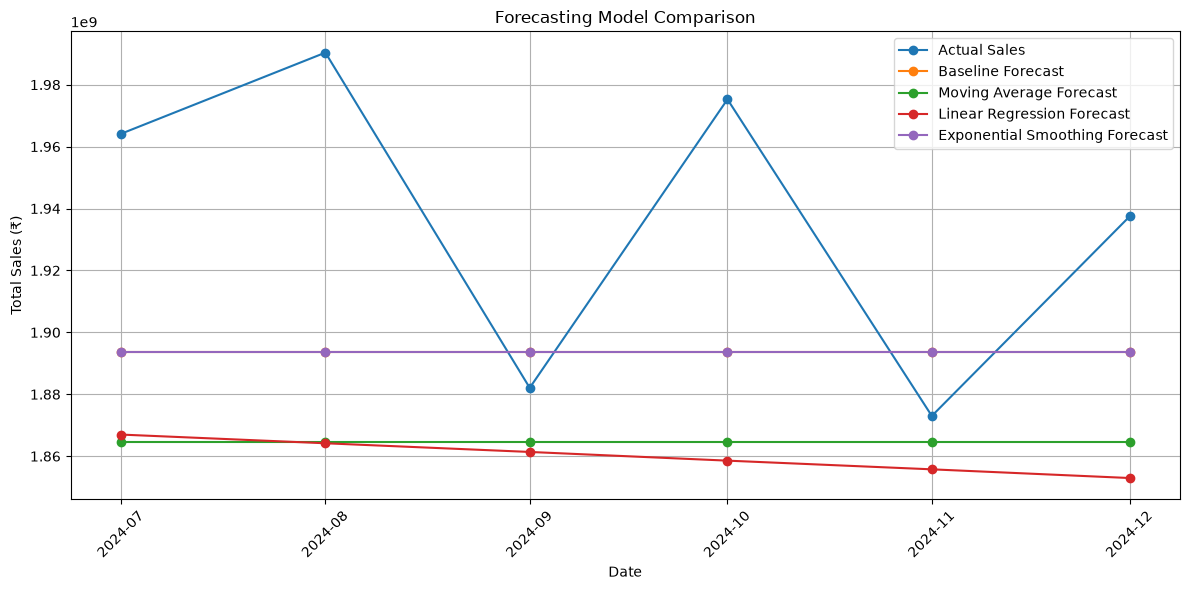

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test["Date"],
    test["Total_Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    test["Baseline_Forecast"],
    marker="o",
    label="Baseline Forecast"
)

plt.plot(
    test["Date"],
    test["Moving_Average_Forecast"],
    marker="o",
    label="Moving Average Forecast"
)

plt.plot(
    test["Date"],
    test["Linear_Forecast"],
    marker="o",
    label="Linear Regression Forecast"
)

plt.plot(
    test["Date"],
    test["ES_Forecast"],
    marker="o",
    label="Exponential Smoothing Forecast"
)

plt.title("Forecasting Model Comparison")
plt.xlabel("Date")
plt.ylabel("Total Sales (₹)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_percentage_error

In [25]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Moving Average",
        "Linear Regression",
        "Exponential Smoothing"
    ],
    "MAE": [
        mean_absolute_error(test["Total_Sales"], test["Baseline_Forecast"]),
        mean_absolute_error(test["Total_Sales"], test["Moving_Average_Forecast"]),
        mean_absolute_error(test["Total_Sales"], test["Linear_Forecast"]),
        mean_absolute_error(test["Total_Sales"], test["ES_Forecast"])
    ],
    "RMSE": [
        mean_squared_error(test["Total_Sales"], test["Baseline_Forecast"]) ** 0.5,
        mean_squared_error(test["Total_Sales"], test["Moving_Average_Forecast"]) ** 0.5,
        mean_squared_error(test["Total_Sales"], test["Linear_Forecast"]) ** 0.5,
        mean_squared_error(test["Total_Sales"], test["ES_Forecast"]) ** 0.5
    ],
    "MAPE (%)": [
        mean_absolute_percentage_error(test["Total_Sales"], test["Baseline_Forecast"]) * 100,
        mean_absolute_percentage_error(test["Total_Sales"], test["Moving_Average_Forecast"]) * 100,
        mean_absolute_percentage_error(test["Total_Sales"], test["Linear_Forecast"]) * 100,
        mean_absolute_percentage_error(test["Total_Sales"], test["ES_Forecast"]) * 100
    ]
})

model_comparison

,Model,MAE,RMSE,MAPE (%)
0,Baseline,5.413397e+07,6.252849e+07,2.759324
1,Moving Average,7.243229e+07,8.528187e+07,3.686829
2,Linear Regression,7.707813e+07,8.835719e+07,3.929244
3,Exponential Smoothing,5.413397e+07,6.252850e+07,2.759324


In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Create the final Exponential Smoothing model
final_es_model = ExponentialSmoothing(
    train["Total_Sales"],
    trend=None,
    seasonal=None
).fit()

print("Final Exponential Smoothing model created successfully!")

Final Exponential Smoothing model created successfully!


In [36]:
# Forecast the next 6 months
future_forecast = final_es_model.forecast(6)

print("===== NEXT 6 MONTH SALES FORECAST =====")
print(future_forecast)

===== NEXT 6 MONTH SALES FORECAST =====
18    1.893655e+09
19    1.893655e+09
20    1.893655e+09
21    1.893655e+09
22    1.893655e+09
23    1.893655e+09
dtype: float64


In [39]:
# Train final Exponential Smoothing model with trend
final_model = ExponentialSmoothing(
    monthly_sales["Total_Sales"],
    trend="add",
    seasonal=None,
    damped_trend=True
).fit()

# Forecast next 6 months
future_forecast = final_model.forecast(6)

print("===== FINAL 6-MONTH SALES FORECAST =====")
print(future_forecast)

===== FINAL 6-MONTH SALES FORECAST =====
24    1.907873e+09
25    1.907921e+09
26    1.907961e+09
27    1.907995e+09
28    1.908025e+09
29    1.908049e+09
dtype: float64


In [40]:
# Create future forecast dates
future_dates = pd.date_range(
    start=monthly_sales["Date"].max() + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

# Create forecast DataFrame
future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Sales": future_forecast.values
})

# Display forecast
future_forecast_df

,Date,Forecast_Sales
0,2025-01-01,1.907873e+09
1,2025-02-01,1.907921e+09
2,2025-03-01,1.907961e+09
3,2025-04-01,1.907995e+09
4,2025-05-01,1.908025e+09
5,2025-06-01,1.908049e+09


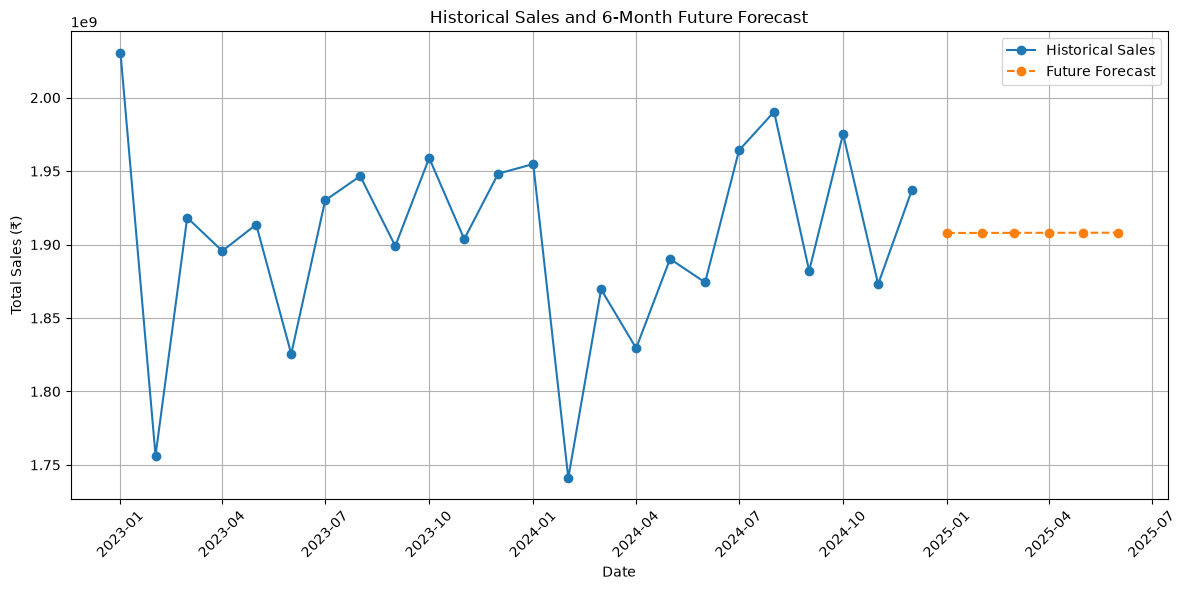

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Historical monthly sales
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Total_Sales"],
    marker="o",
    label="Historical Sales"
)

# Future forecast
plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecast_Sales"],
    marker="o",
    linestyle="--",
    label="Future Forecast"
)

plt.title("Historical Sales and 6-Month Future Forecast")
plt.xlabel("Date")
plt.ylabel("Total Sales (₹)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [43]:
forecast_file_path = "../data/future_sales_forecast.csv"

future_forecast_df.to_csv(
    forecast_file_path,
    index=False
)

print("Future forecast saved successfully!")
print("File:", forecast_file_path)

Future forecast saved successfully!
File: ../data/future_sales_forecast.csv


In [44]:
# Verify the final forecast saved to CSV

check_forecast = pd.read_csv("../data/future_sales_forecast.csv")

print("===== SAVED FORECAST =====")
print(check_forecast)

===== SAVED FORECAST =====
         Date  Forecast_Sales
0  2025-01-01    1.907873e+09
1  2025-02-01    1.907921e+09
2  2025-03-01    1.907961e+09
3  2025-04-01    1.907995e+09
4  2025-05-01    1.908025e+09
5  2025-06-01    1.908049e+09


In [45]:
import joblib
import os

# Create models folder if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the final forecasting model
joblib.dump(final_model, "../models/final_forecasting_model.pkl")

print("Final forecasting model saved successfully!")

Final forecasting model saved successfully!
